In [1]:
import numpy as np

In [8]:
x, w = np.polynomial.legendre.leggauss(5)
x , w

(array([-0.90617985, -0.53846931,  0.        ,  0.53846931,  0.90617985]),
 array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689]))

In [9]:
def legendre_quadrature(f,a,b,n):
    x, w = np.polynomial.legendre.leggauss(n)

    t = 0.5 * (x+1) * (b-a) + a
    ft = f(t)
    result = 0.5 * (b-a) * (w @ ft) 

    return result

In [10]:
f = lambda x: np.sin(x)
legendre_quadrature(f,0,np.pi,3)

2.0013889136077436

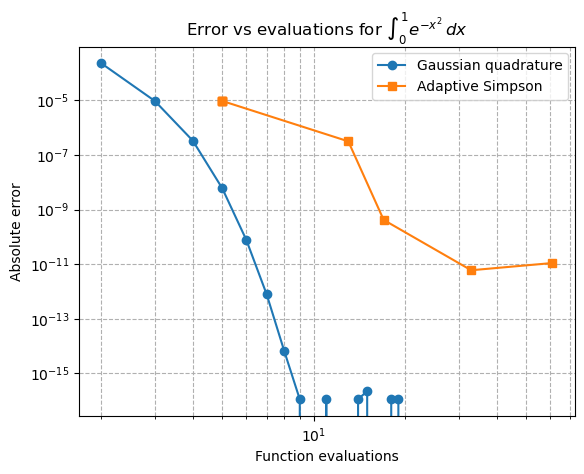

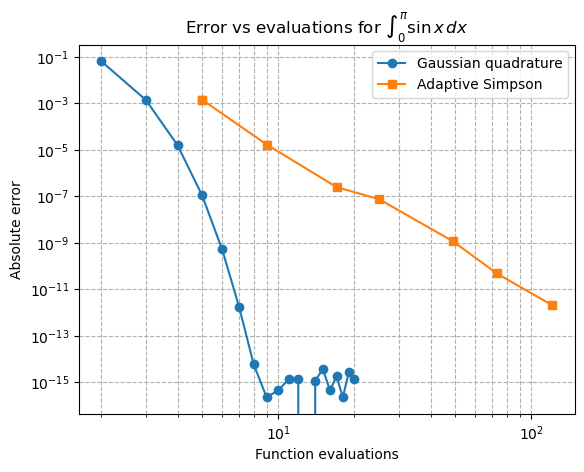

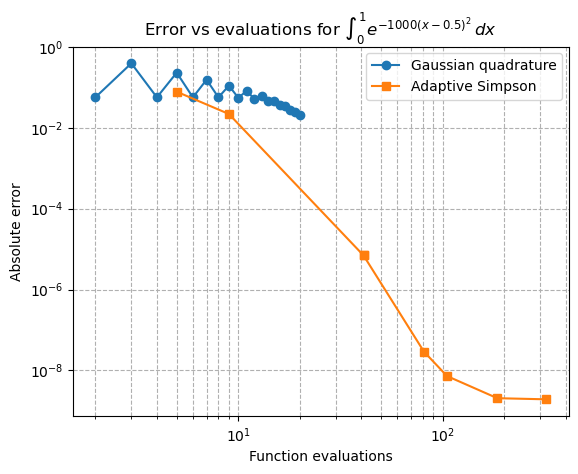

In [12]:
import numpy as np
import math
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Adaptive Simpson implementation with automatic function-call counting
# ------------------------------------------------------------
def adaptive_simpson(f, a, b, eps=1e-8, max_depth=20):
    """Return (approximation, function_evaluations)."""

    evals = 0

    def fs(x):
        nonlocal evals
        evals += 1
        return f(x)

    def simpson_rule(fa, fb, fc, h):
        return h * (fa + 4 * fc + fb) / 6.0

    def recurse(a, b, fa, fb, fc, S, eps, depth):
        c = 0.5 * (a + b)
        h = b - a
        d = 0.5 * (a + c)
        e = 0.5 * (c + b)
        fd = fs(d)
        fe = fs(e)

        S_left = simpson_rule(fa, fc, fd, h * 0.5)
        S_right = simpson_rule(fc, fb, fe, h * 0.5)

        if depth <= 0 or abs(S_left + S_right - S) <= 15 * eps:
            return S_left + S_right + (S_left + S_right - S) / 15.0
        return (
            recurse(a, c, fa, fc, fd, S_left, eps / 2, depth - 1)
            + recurse(c, b, fc, fb, fe, S_right, eps / 2, depth - 1)
        )

    c = 0.5 * (a + b)
    fa, fb, fc = fs(a), fs(b), fs(c)
    S0 = simpson_rule(fa, fb, fc, b - a)
    result = recurse(a, b, fa, fb, fc, S0, eps, max_depth)
    return result, evals


# ------------------------------------------------------------
# Gaussian quadrature helper
# ------------------------------------------------------------
def gaussian_quadrature(f, a, b, n):
    """Return (approximation, function_evaluations) with n‑point Gauss–Legendre."""
    x, w = np.polynomial.legendre.leggauss(n)
    t = 0.5 * (b - a) * x + 0.5 * (a + b)
    ft = [f(tt) for tt in t]
    result = 0.5 * (b - a) * np.dot(w, ft)
    return result, len(ft)


# ------------------------------------------------------------
# Example integrands
# ------------------------------------------------------------
examples = [
    {
        "name": r"$\int_{0}^{1} e^{-x^2}\,dx$",
        "f": lambda x: math.exp(-x * x),
        "a": 0.0,
        "b": 1.0,
        "exact": 0.5 * math.sqrt(math.pi) * math.erf(1.0),
    },
    {
        "name": r"$\int_{0}^{\pi} \sin x\,dx$",
        "f": math.sin,
        "a": 0.0,
        "b": math.pi,
        "exact": 2.0,
    },
    {
        "name": r"$\int_{0}^{1} e^{-1000(x-0.5)^2}\,dx$",
        "f": lambda x: math.exp(-1000.0 * (x - 0.5) ** 2),
        "a": 0.0,
        "b": 1.0,
        "exact": math.sqrt(math.pi/1000) * math.erf(math.sqrt(1000)/2),
    },
]

# ------------------------------------------------------------
# Comparison loop
# ------------------------------------------------------------
gauss_ns = range(2, 21)  # 2‑ to 10‑point Gaussian rules
simpson_epsilons = [10 ** (-k) for k in range(1, 9)]  # 1e‑1 … 1e‑8

for ex in examples:
    f, a, b, exact, label = ex["f"], ex["a"], ex["b"], ex["exact"], ex["name"]

    # Gaussian results
    g_counts, g_errors = [], []
    for n in gauss_ns:
        val, cnt = gaussian_quadrature(f, a, b, n)
        g_counts.append(cnt)
        g_errors.append(abs(val - exact))

    # Adaptive Simpson results
    s_counts, s_errors = [], []
    for eps in simpson_epsilons:
        val, cnt = adaptive_simpson(f, a, b, eps)
        s_counts.append(cnt)
        s_errors.append(abs(val - exact))

    # Plot
    plt.figure()
    plt.loglog(g_counts, g_errors, marker="o", label="Gaussian quadrature")
    plt.loglog(s_counts, s_errors, marker="s", label="Adaptive Simpson")
    plt.xlabel("Function evaluations")
    plt.ylabel("Absolute error")
    plt.title(f"Error vs evaluations for {label}")
    plt.legend()
    plt.grid(True, which="both", linestyle="--")
    plt.show()


